In [1]:
import json
import numpy as np
import pandas as pd
import torch
import geopandas as gpd

# Filter dataset 

This section only works after downloading the yelp data from https://yelp.com/dataset

In [2]:
!ls ../../yelp/yelp/

Dataset_User_Agreement.pdf          yelp_academic_dataset_review.json
yelp_academic_dataset_business.json yelp_academic_dataset_tip.json
yelp_academic_dataset_checkin.json  yelp_academic_dataset_user.json


In [2]:
with open('../../yelp/yelp/yelp_academic_dataset_business.json', 'r') as handle:
    business = [json.loads(line) for line in handle]

with open('../../yelp/yelp/yelp_academic_dataset_user.json', 'r') as handle:
    user = [json.loads(line) for line in handle]

with open('../../yelp/yelp/yelp_academic_dataset_review.json', 'r') as handle:
    review = [json.loads(line) for line in handle]


In [3]:
business = pd.DataFrame.from_dict(business)
user = pd.DataFrame.from_dict(user)
review = pd.DataFrame.from_dict(review)

In [4]:
# whole dataset preprocessing
business.dropna(subset=['categories', 'postal_code'], inplace=True)


review['year'] = review['date'].apply(lambda x: x[:4]).astype(int)
review['year'].value_counts().sort_index()

year
2005       854
2006      3853
2007     15363
2008     48226
2009     74387
2010    138587
2011    230813
2012    286570
2013    383950
2014    522275
2015    688415
2016    758882
2017    820048
2018    906362
2019    907284
2020    554557
2021    618189
2022     31665
Name: count, dtype: int64

In [5]:
len(review)

6990280

In [7]:
review_2019 = review[review['year'] <= 2019]
len(review_2019)

0.8277020376866163

In [8]:
len(review_2019)/len(review)

0.8277020376866163

In [5]:
review.columns

Index(['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
       'cool', 'text', 'date'],
      dtype='object')

In [10]:
# whole dataset preprocessing

review = review[review['year'] <= 2019]

review = review[['user_id', 'business_id', 'stars', 'date', 'year']]

user_reviews_counts = review['user_id'].value_counts()
user_reviews_counts = user_reviews_counts[user_reviews_counts >= 10]

user = user[user['user_id'].isin(user_reviews_counts.index)]
review = review[review['user_id'].isin(user_reviews_counts.index)]
business = business[business['business_id'].isin(review['business_id'])]

business.to_csv('yelp2019_business.csv', index=False)
review.to_csv('yelp2019_review.csv', index=False)
user.to_csv('yelp2019_user.csv', index=False)

business['categories'] = business['categories'].apply(lambda x: x.split(', '))

all_categories = business['categories'].explode().value_counts()

# remove Restaurants, Food, Shopping, Specialty Food and Nightlife
all_categories = all_categories[~all_categories.index.isin(['Restaurants', 'Food', 'Shopping', 'Specialty Food', 'Nightlife'])]

# select the top 50 categories
all_categories = all_categories.head(50)


business_categories = {}

for category in all_categories.index:
    category_column = []
    for index, row in business.iterrows():
        category_column.append(category in row['categories'])

    business_categories[category] = category_column
business_categories = pd.DataFrame(business_categories, index=business.business_id)

business_categories.to_csv('yelp2019_business_categories.csv')

ValueError: Length of values (12935) does not match length of index (135149)

In [13]:
from shapely.geometry import Point
from tqdm import tqdm
# add block groups id to business

business_df = pd.read_csv('../datasets/yelp2019_business.csv')

# only for business in PA, IN, MO, TN and FL
business_df['block_group_id'] = None

states_with_block_groups = ['PA', 'IN', 'MO', 'TN', 'FL', 'IL', 'NJ', 'DE']
states_to_urban_areas = {
    'PA': 'Philadelphia',
    'NJ': 'Philadelphia',
    'DE': 'Philadelphia',
    'IN': 'Indianapolis',
    'IL': 'St. Louis',
    'MO': 'St. Louis',
    'TN': 'Nashville',
    'FL': 'Tampa',
    }

states_block_shapes = {}
for state in states_with_block_groups:
    blocks_shapes = gpd.read_file(f'../datasets/{state}_bg.zip')
    blocks_shapes = blocks_shapes[['GEOID', 'geometry']]
    blocks_shapes.rename(columns={'GEOID': 'block_group_id'}, inplace=True)
    blocks_shapes['block_group_id'] = blocks_shapes['block_group_id'].astype(str)
    states_block_shapes[state] = blocks_shapes





for index, row in tqdm(business_df.iterrows(), total=business_df.shape[0]):
    for state in states_with_block_groups:
        blocks_shapes = states_block_shapes[state]
        point = Point(row['longitude'], row['latitude'])
        block_group = blocks_shapes[blocks_shapes.contains(point)]
        if not block_group.empty:
            business_df.at[index, 'block_group_id'] = block_group['block_group_id'].values[0]
            business_df.at[index, 'urban_area'] = states_to_urban_areas[state]

business_df['block_group_id'] = business_df['block_group_id'].astype(str)


business_df.to_csv('../datasets/yelp2019_business.csv', index=False)

100%|██████████| 135149/135149 [43:01<00:00, 52.36it/s] 


In [15]:
business_df.loc[(business_df['urban_area'] == 'Philadelphia') &  (business_df['state'] == 'NJ')].block_group_id.unique()

array(['340076033011', '340155016031', '340057011023', '340076104003',
       '340076075053', '340155011021', '340057005022', '340210037073',
       '340076082022', '340076075022', '340210017003', '340076068002',
       '340076074011', '340057004082', '340076091032', '340155014062',
       '340076062002', '340330215001', '340076060001', '340057038022',
       '340155020013', '340057001021', '340076035011', '340155010022',
       '340057001041', '340076084031', '340330208002', '340076034003',
       '340057040061', '340057007021', '340190119002', '340190119003',
       '340057013012', '340155014021', '340057040044', '340155012023',
       '340076036011', '340057006022', '340076034002', '340076043001',
       '340076032013', '340057029134', '340076039011', '340057003032',
       '340057005041', '340076089042', '340155012062', '340057029052',
       '340076034001', '340057029103', '340076088002', '340155014051',
       '340057003062', '340076065001', '340076036031', '340155016082',
      

(39.6, 40.5)

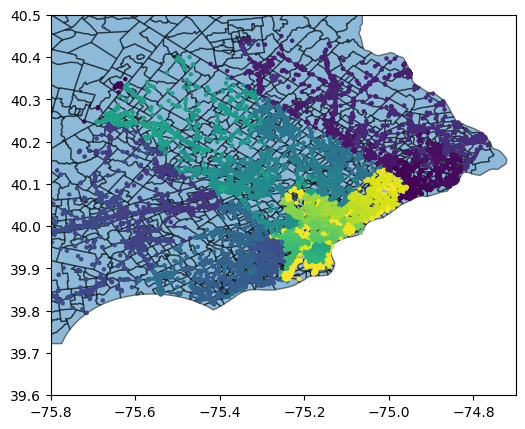

In [29]:
from shapely.geometry import Point
# add block groups id to business

business_df = pd.read_csv('../datasets/yelp2019_business.csv')

state = 'PA'

business_df = business_df[business_df['state'] == state]
# remove businesses without block group id
business_df = business_df[business_df['block_group_id'].notna()]

blocks_shapes = gpd.read_file(f'../datasets/{state}_bg.zip')
# plot the block groups
# and the business points, with colors based on the block group id
business_df['geometry'] = business_df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
business_gdf = gpd.GeoDataFrame(business_df, geometry='geometry')
color_map = business_gdf['block_group_id'].astype('category').cat.codes

ax = blocks_shapes.plot(figsize=(6, 6*((75.8-74.7)/(40.5-39.6))), alpha=0.5, edgecolor='black')
# plot the business points with colors based on the block group id
business_gdf.plot(ax=ax, c=color_map, markersize=5, legend=True)

# restricting between 39.6 and 40.5 latitude and -75.8 and -74.7 longitude
ax.set_xlim([-75.8, -74.7])
ax.set_ylim([39.6, 40.5])



In [28]:
6*((75.8-74.7)/(40.5-39.6))

7.333333333333307

# Save pyg version

In [1]:
import torch
from torch_geometric import seed_everything
import pandas as pd
from torch_geometric.data import HeteroData, Data
import torch_geometric.transforms as T
import numpy as np
from torch_geometric.loader import LinkNeighborLoader, NeighborLoader
import torch_geometric.utils as tgu
from torch_geometric import EdgeIndex

/home/fpnerini/miniconda3/envs/pyg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
business_df = pd.read_csv('../datasets/yelp2019_business.csv', index_col='business_id')
business_feat_df = pd.read_csv('../datasets/yelp2019_business_categories.csv', index_col='business_id')
business_df.columns

Index(['name', 'address', 'city', 'state', 'postal_code', 'latitude',
       'longitude', 'stars', 'review_count', 'is_open', 'attributes',
       'categories', 'hours', 'block_group_id'],
      dtype='object')

In [3]:
business_df = pd.read_csv('../datasets/yelp2019_business.csv', index_col='business_id')
business_feat_df = pd.read_csv('../datasets/yelp2019_business_categories.csv', index_col='business_id')


pc_unique_values = business_df['postal_code'].unique()
np.random.shuffle(pc_unique_values)
postal_code_map = pd.Series(np.arange(len(pc_unique_values)), index=pc_unique_values, ) 
postal_codes = postal_code_map[business_df['postal_code']].values
block_group_map = pd.Series(np.arange(len(business_df['block_group_id'].unique())), index=business_df['block_group_id'].unique())
block_groups = block_group_map[business_df['block_group_id']].values

# Use business info as features:
business_feat = business_feat_df.values.astype(np.float32)
business_feat = torch.from_numpy(business_feat).to(torch.float)

review_df = pd.read_csv('../datasets/yelp2019_review.csv')
review_df = review_df.loc[review_df['business_id'].isin(business_df.index)]

unique_user_id = review_df['user_id'].unique()
unique_user_id = pd.DataFrame(data={
    'user_id': unique_user_id,
    'mapped_id': pd.RangeIndex(len(unique_user_id)),
})

unique_business_id = pd.DataFrame(data={
    'business_id': business_df.index,
    'mapped_id': pd.RangeIndex(len(business_df)),
})

reviews_user_id = pd.merge(review_df['user_id'], unique_user_id,
                            left_on='user_id', right_on='user_id', how='left')
reviews_user_id = torch.from_numpy(reviews_user_id['mapped_id'].values)
reviews_business_id = pd.merge(review_df['business_id'], unique_business_id,
                            left_on='business_id', right_on='business_id', how='left')
reviews_business_id = torch.from_numpy(reviews_business_id['mapped_id'].values)

edge_index_user_to_business = torch.stack([reviews_user_id, reviews_business_id], dim=0)
data = HeteroData()

# Save node indices:
data["user"].node_id = torch.arange(len(unique_user_id))
data["business"].node_id = torch.arange(len(business_df))

# Add the node features and edge indices:
data["business"].x = business_feat
data["user", "rates", "business"].edge_index = edge_index_user_to_business

# Add business coordinates, transformed from lat/long to 3d positions
coords = business_df[["latitude", "longitude"]].to_numpy()
coords = np.deg2rad(coords)
coords = np.stack([np.cos(coords[:, 0]) * np.cos(coords[:, 1]),
                np.cos(coords[:, 0]) * np.sin(coords[:, 1]),
                np.sin(coords[:, 0])], axis=-1)

#x = torch.from_numpy(np.cos(coords[0])*np.cos(coords[1]))
#y = torch.from_numpy(np.cos(coords[0])*np.sin(coords[1]))
#z = torch.from_numpy(np.sin(coords[0]))

data["business"].pos = torch.from_numpy(coords).to(torch.float)
data["business"].pc =  torch.from_numpy(postal_codes).to(torch.int64)
data["business"].bg = torch.from_numpy(block_groups).to(torch.int64)
data["business"].latitude = torch.from_numpy(business_df['latitude'].to_numpy()).to(torch.float)
data["business"].longitude = torch.from_numpy(business_df['longitude'].to_numpy()).to(torch.float)
# We also need to make sure to add the reverse edges from business to users
# in order to let a GNN be able to pass messages in both directions.
# We can leverage the `T.ToUndirected()` transform for this from PyG:

data.num_users = data['user'].num_nodes
data.num_businesses = data['business'].num_nodes

transform = T.ToUndirected()
data = transform(data)

torch.save(data, '../datasets/yelp2019.pt')

# Maps

In [3]:
map_gpd = gpd.read_file('../datasets/ne_110m_admin_1_states_provinces.zip')

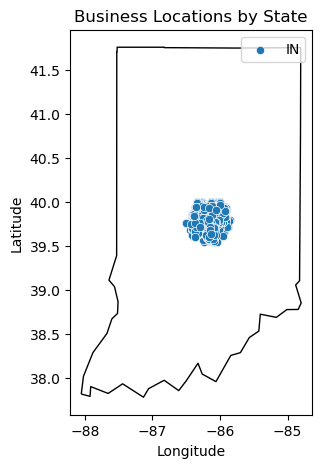

In [10]:
business_df = pd.read_csv('../datasets/yelp2019_business.csv', index_col='business_id')

import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

fig = plt.figure(figsize=(15, 5))

states = ['IN']
for i, state in enumerate(states):
    state_business = business_df[business_df['state'] == state]
    sns.scatterplot(data=state_business, x='longitude', y='latitude', label=state)

# finally plot the USA state boundaries excluding Alaska and Hawaii
map_gpd[map_gpd['name'].isin(['Indiana'])].boundary.plot(ax=plt.gca(), color='black', linewidth=1)
plt.title('Business Locations by State')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend()